In [29]:
import pandas as pd

# 1. 加载合并后的污染数据
merged_df = pd.read_csv("合并后的数据.csv")

# 2. 创建地名与经纬度字典
location_dict = {
    "高压开关厂": (34.259781, 108.856987),
    "兴庆小区": (34.261593, 108.98996),
    "纺织城": (34.279709, 109.07048),
    "小寨": (34.22282, 108.947144),
    "市人民体育场": (34.26955, 108.95903),
    "高新西区": (34.233376, 108.9049),
    "经开区": (34.35886, 108.929192),
    "长安区": (34.158932, 108.90696),
    "阎良区": (34.662251, 109.226196),
    "临潼区": (34.366699, 109.214211),
    "曲江文化集团": (34.209648, 108.977669),
    "广运潭": (34.354256, 109.011482),"世园会广运潭": (34.354256, 109.011482),
    "草滩": (34.382896, 108.88327)
}

# 3. 构造经纬度 DataFrame
location_df = pd.DataFrame.from_dict(
    location_dict, 
    orient='index', 
    columns=['纬度', '经度']
).reset_index().rename(columns={'index': '点位名称'})

# 4. 清洗点位名称，确保合并不会因空格失败
def clean_location(s):
    return str(s).strip().replace('\u3000', '').replace(' ', '')

merged_df['点位名称'] = merged_df['点位名称'].apply(clean_location)
location_df['点位名称'] = location_df['点位名称'].apply(clean_location)

# 5. 合并经纬度信息
merged_with_location = pd.merge(
    merged_df,
    location_df,
    on='点位名称',
    how='left'  # 保留污染数据中所有记录
)

# 6. 保存合并后的数据
merged_with_location.to_csv("合并带经纬度的数据.csv", index=False, encoding='utf-8-sig')

# 7. 检查是否有未匹配成功的点位（可选）
unmatched = merged_with_location[merged_with_location['纬度'].isna()]
if not unmatched.empty:
    print("⚠️ 以下点位未成功匹配经纬度：")
    print(unmatched['点位名称'].unique())
else:
    print("✅ 所有点位经纬度匹配成功！")
# 删掉点位名称
merged_with_location = merged_with_location.drop(columns=['点位名称'])
# 经纬度放在第一二列
merged_with_location = merged_with_location[['纬度', '经度'] + [col for col in merged_with_location.columns if col not in ['纬度', '经度']]]
# 保存最终结果
merged_with_location.to_csv("最终合并带经纬度的数据.csv", index=False, encoding='utf-8-sig')

✅ 所有点位经纬度匹配成功！


加载数据...
数据形状: (20198, 34)
数据列: ['纬度', '经度', 'SO2', 'NO2', 'PM10', '污染程度', '日期', '时间段', '气温', '风向编码', '风力编码', '降水强度', '天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘', '年', '月', '日', '星期', '天气类别', 'sin_月', 'cos_月', 'sin_日', 'cos_日', 'sin_星期', 'cos_星期', '位置hash', '污染物总和', '污染物比例_SO2', '污染物比例_NO2', '污染物比例_PM10']
天气类别: ['雪' '阴' '多云' '雾霾沙尘' '晴' '雨']
数据日期范围: 2011-01-02 00:00:00 到 2013-04-26 00:00:00

训练模型...
开始数据预处理...
创建时序序列...
天气类别数: 6
最大风力: 4
最大降水强度: 4
构建LSTM模型...
模型结构:
Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 12, 18)]     0           []                               
                                                                                                  
 lstm_4 (LSTM)                  (None, 12, 128)      75264       ['input_5[0][0]']                
              

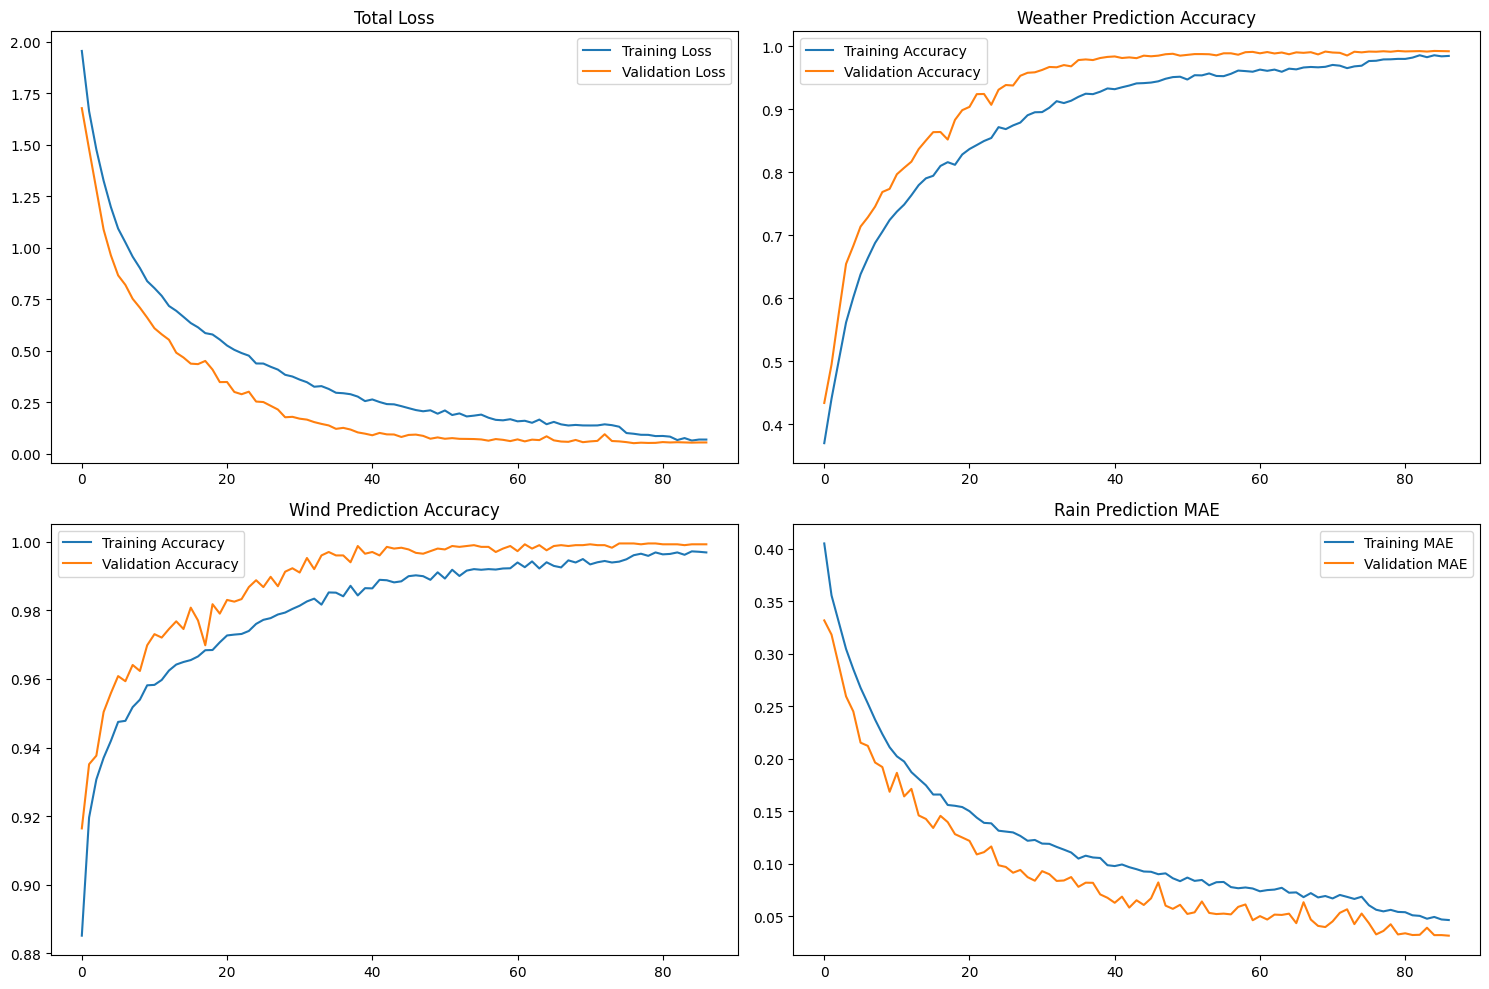


进行示例预测...


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Input, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

# 设置随机种子
np.random.seed(42)
tf.random.set_seed(42)

class EnvironmentalPredictor:
    def __init__(self):
        self.scaler_features = StandardScaler()
        self.scaler_continuous_targets = StandardScaler()
        self.weather_encoder = None
        self.is_fitted = False
    def save_model(self, model_path='saved_model'):
        """保存模型及预处理器"""
        if not self.is_fitted:
            raise ValueError("模型尚未训练，无法保存。")

        os.makedirs(model_path, exist_ok=True)
        
        # 保存 Keras 模型
        self.model.save(os.path.join(model_path, 'model.h5'))

        # 保存缩放器和编码器
        joblib.dump(self.scaler_features, os.path.join(model_path, 'scaler_features.pkl'))
        joblib.dump(self.weather_encoder, os.path.join(model_path, 'weather_encoder.pkl'))

        # 保存元信息
        with open(os.path.join(model_path, 'meta_info.txt'), 'w') as f:
            f.write(f"use_sequences={self.use_sequences}\n")
            if self.use_sequences:
                f.write(f"sequence_length={self.sequence_length}\n")
        
        print(f"模型和预处理器已保存至：{model_path}")
    def load_model(self, model_path='saved_model'):
        """加载模型及预处理器"""
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"模型路径不存在: {model_path}")

        # 加载 Keras 模型
        self.model = tf.keras.models.load_model(os.path.join(model_path, 'model.h5'))

        # 加载缩放器和编码器
        self.scaler_features = joblib.load(os.path.join(model_path, 'scaler_features.pkl'))
        self.weather_encoder = joblib.load(os.path.join(model_path, 'weather_encoder.pkl'))

        # 读取元信息
        meta_info_path = os.path.join(model_path, 'meta_info.txt')
        if os.path.exists(meta_info_path):
            with open(meta_info_path, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    if line.startswith("use_sequences="):
                        self.use_sequences = line.strip().split('=')[1].lower() == 'true'
                    elif line.startswith("sequence_length="):
                        self.sequence_length = int(line.strip().split('=')[1])
        
        self.is_fitted = True
        print(f"模型和预处理器已从 {model_path} 成功加载。")

    def load_and_preprocess_data(self, file_path):
        """加载和预处理数据"""
        # 读取数据
        columns = ['纬度', '经度', 'SO2', 'NO2', 'PM10', '污染程度', '日期', '时间段', 
                  '气温', '风向编码', '风力编码', '降水强度', '天气_多云', '天气_晴', 
                  '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘']
        
        data = pd.read_csv(file_path)
        
        # 处理日期
        data['日期'] = pd.to_datetime(data['日期'])
        data['年'] = data['日期'].dt.year
        data['月'] = data['日期'].dt.month
        data['日'] = data['日期'].dt.day
        data['星期'] = data['日期'].dt.dayofweek
        
        # 创建天气标签（从one-hot转换）
        weather_cols = ['天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘']
        data['天气类别'] = data[weather_cols].idxmax(axis=1).str.replace('天气_', '')
        
        # 特征工程：添加时间特征
        data['sin_月'] = np.sin(2 * np.pi * data['月'] / 12)
        data['cos_月'] = np.cos(2 * np.pi * data['月'] / 12)
        data['sin_日'] = np.sin(2 * np.pi * data['日'] / 31)
        data['cos_日'] = np.cos(2 * np.pi * data['日'] / 31)
        data['sin_星期'] = np.sin(2 * np.pi * data['星期'] / 7)
        data['cos_星期'] = np.cos(2 * np.pi * data['星期'] / 7)
        
        # 添加空间特征
        data['位置hash'] = data['纬度'].astype(str) + '_' + data['经度'].astype(str)
        
        # 添加污染物综合指标
        data['污染物总和'] = data['SO2'] + data['NO2'] + data['PM10']
        data['污染物比例_SO2'] = data['SO2'] / (data['污染物总和'] + 1e-8)
        data['污染物比例_NO2'] = data['NO2'] / (data['污染物总和'] + 1e-8)
        data['污染物比例_PM10'] = data['PM10'] / (data['污染物总和'] + 1e-8)
        
        return data
    
    def create_sequences(self, data, sequence_length=24):
        """创建时序序列数据"""
        # 按位置分组
        grouped = data.groupby('位置hash')
        
        sequences_X = []
        sequences_y_weather = []
        sequences_y_wind = []
        sequences_y_rain = []
        
        for location, group in grouped:
            if len(group) < sequence_length + 1:
                continue
                
            group_sorted = group.sort_values(['日期', '时间段'])
            
            for i in range(len(group_sorted) - sequence_length):
                # 输入特征序列
                seq_features = ['纬度', '经度', 'SO2', 'NO2', 'PM10', '污染程度', 
                              '时间段', '气温', 'sin_月', 'cos_月', 'sin_日', 'cos_日', 
                              'sin_星期', 'cos_星期', '污染物总和', '污染物比例_SO2', 
                              '污染物比例_NO2', '污染物比例_PM10']
                
                seq_X = group_sorted[seq_features].iloc[i:i+sequence_length].values
                
                # 目标变量（预测下一个时间点）
                target_row = group_sorted.iloc[i+sequence_length]
                
                sequences_X.append(seq_X)
                sequences_y_weather.append(target_row['天气类别'])
                sequences_y_wind.append(target_row['风力编码'])
                sequences_y_rain.append(target_row['降水强度'])
        
        return np.array(sequences_X), np.array(sequences_y_weather), np.array(sequences_y_wind), np.array(sequences_y_rain)
    
    def prepare_non_sequential_data(self, data):
        """准备非时序数据"""
        # 输入特征
        feature_cols = ['纬度', '经度', 'SO2', 'NO2', 'PM10', '污染程度', 
                       '时间段', '气温', 'sin_月', 'cos_月', 'sin_日', 'cos_日', 
                       'sin_星期', 'cos_星期', '污染物总和', '污染物比例_SO2', 
                       '污染物比例_NO2', '污染物比例_PM10']
        
        X = data[feature_cols].values
        y_weather = data['天气类别'].values
        y_wind = data['风力编码'].values
        y_rain = data['降水强度'].values
        
        return X, y_weather, y_wind, y_rain
    
    def build_lstm_model(self, input_shape, n_weather_classes, max_wind, max_rain):
        """构建LSTM多输出模型"""
        # 输入层
        input_layer = Input(shape=input_shape)
        
        # LSTM层
        lstm1 = LSTM(128, return_sequences=True, dropout=0.2)(input_layer)
        lstm2 = LSTM(64, dropout=0.2)(lstm1)
        
        # 批归一化
        bn = BatchNormalization()(lstm2)
        
        # 共享的全连接层
        shared_dense = Dense(64, activation='relu')(bn)
        shared_dense = Dropout(0.3)(shared_dense)
        
        # 天气预测分支
        weather_branch = Dense(32, activation='relu', name='weather_dense')(shared_dense)
        weather_output = Dense(n_weather_classes, activation='softmax', name='weather_output')(weather_branch)
        
        # 风力预测分支
        wind_branch = Dense(32, activation='relu', name='wind_dense')(shared_dense)
        wind_output = Dense(max_wind + 1, activation='softmax', name='wind_output')(wind_branch)
        
        # 降水预测分支
        rain_branch = Dense(32, activation='relu', name='rain_dense')(shared_dense)
        rain_output = Dense(1, activation='linear', name='rain_output')(rain_branch)
        
        # 构建模型
        model = Model(inputs=input_layer, 
                     outputs=[weather_output, wind_output, rain_output])
        
        return model
    
    def build_dense_model(self, input_shape, n_weather_classes, max_wind, max_rain):
        """构建全连接多输出模型"""
        # 输入层
        input_layer = Input(shape=(input_shape,))
        
        # 隐藏层
        dense1 = Dense(256, activation='relu')(input_layer)
        dense1 = BatchNormalization()(dense1)
        dense1 = Dropout(0.3)(dense1)
        
        dense2 = Dense(128, activation='relu')(dense1)
        dense2 = BatchNormalization()(dense2)
        dense2 = Dropout(0.3)(dense2)
        
        dense3 = Dense(64, activation='relu')(dense2)
        dense3 = Dropout(0.2)(dense3)
        
        # 天气预测分支
        weather_branch = Dense(32, activation='relu')(dense3)
        weather_output = Dense(n_weather_classes, activation='softmax', name='weather_output')(weather_branch)
        
        # 风力预测分支
        wind_branch = Dense(32, activation='relu')(dense3)
        wind_output = Dense(max_wind + 1, activation='softmax', name='wind_output')(wind_branch)
        
        # 降水预测分支
        rain_branch = Dense(32, activation='relu')(dense3)
        rain_output = Dense(1, activation='linear', name='rain_output')(rain_branch)
        
        # 构建模型
        model = Model(inputs=input_layer, 
                     outputs=[weather_output, wind_output, rain_output])
        
        return model
    
    def train_models(self, data, use_sequences=True, sequence_length=24):
        """训练模型"""
        print("开始数据预处理...")
        
        # 编码器准备
        from sklearn.preprocessing import LabelEncoder
        self.weather_encoder = LabelEncoder()
        weather_encoded = self.weather_encoder.fit_transform(data['天气类别'])
        
        if use_sequences:
            print("创建时序序列...")
            X, y_weather, y_wind, y_rain = self.create_sequences(data, sequence_length)
            if len(X) == 0:
                print("序列数据不足，切换到非时序模式...")
                use_sequences = False
        
        if not use_sequences:
            print("使用非时序数据...")
            X, y_weather, y_wind, y_rain = self.prepare_non_sequential_data(data)
            
        # 编码目标变量
        y_weather_encoded = self.weather_encoder.transform(y_weather)
        
        # 标准化特征
        if use_sequences:
            # 对于序列数据，需要重塑后标准化
            X_reshaped = X.reshape(-1, X.shape[-1])
            X_scaled_reshaped = self.scaler_features.fit_transform(X_reshaped)
            X_scaled = X_scaled_reshaped.reshape(X.shape)
        else:
            X_scaled = self.scaler_features.fit_transform(X)
        
        # 划分训练测试集
        if use_sequences:
            X_train, X_test, y_weather_train, y_weather_test, y_wind_train, y_wind_test, y_rain_train, y_rain_test = \
                train_test_split(X_scaled, y_weather_encoded, y_wind, y_rain, test_size=0.2, random_state=42)
        else:
            X_train, X_test, y_weather_train, y_weather_test, y_wind_train, y_wind_test, y_rain_train, y_rain_test = \
                train_test_split(X_scaled, y_weather_encoded, y_wind, y_rain, test_size=0.2, random_state=42)
        
        # 获取类别数量
        n_weather_classes = len(self.weather_encoder.classes_)
        max_wind = int(max(y_wind))
        max_rain = int(max(y_rain))
        
        print(f"天气类别数: {n_weather_classes}")
        print(f"最大风力: {max_wind}")
        print(f"最大降水强度: {max_rain}")
        
        # 构建模型
        if use_sequences:
            print("构建LSTM模型...")
            model = self.build_lstm_model(X_train.shape[1:], n_weather_classes, max_wind, max_rain)
        else:
            print("构建全连接模型...")
            model = self.build_dense_model(X_train.shape[1], n_weather_classes, max_wind, max_rain)
        
        # 编译模型
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss={
                'weather_output': 'sparse_categorical_crossentropy',
                'wind_output': 'sparse_categorical_crossentropy',
                'rain_output': 'mse'
            },
            loss_weights={
                'weather_output': 1.0,
                'wind_output': 1.0,
                'rain_output': 0.5
            },
            metrics={
                'weather_output': 'accuracy',
                'wind_output': 'accuracy',
                'rain_output': 'mae'
            }
        )
        
        print("模型结构:")
        model.summary()
        
        # 回调函数
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
        ]
        
        # 训练模型
        print("开始训练...")
        history = model.fit(
            X_train,
            {
                'weather_output': y_weather_train,
                'wind_output': y_wind_train,
                'rain_output': y_rain_train
            },
            validation_data=(
                X_test,
                {
                    'weather_output': y_weather_test,
                    'wind_output': y_wind_test,
                    'rain_output': y_rain_test
                }
            ),
            epochs=100,
            batch_size=32,
            callbacks=callbacks,
            verbose=1
        )
        
        # 评估模型
        print("\n模型评估:")
        predictions = model.predict(X_test)
        
        # 天气预测评估
        weather_pred = np.argmax(predictions[0], axis=1)
        weather_acc = accuracy_score(y_weather_test, weather_pred)
        print(f"天气预测准确率: {weather_acc:.4f}")
        
        # 风力预测评估
        wind_pred = np.argmax(predictions[1], axis=1)
        wind_acc = accuracy_score(y_wind_test, wind_pred)
        print(f"风力预测准确率: {wind_acc:.4f}")
        
        # 降水预测评估
        rain_pred = predictions[2].flatten()
        rain_mse = mean_squared_error(y_rain_test, rain_pred)
        rain_mae = mean_absolute_error(y_rain_test, rain_pred)
        print(f"降水预测 MSE: {rain_mse:.4f}")
        print(f"降水预测 MAE: {rain_mae:.4f}")
        
        # 详细分类报告
        print("\n天气预测详细报告:")
        print(classification_report(y_weather_test, weather_pred, 
                                  target_names=self.weather_encoder.classes_))
        
        self.model = model
        self.is_fitted = True
        self.use_sequences = use_sequences
        self.sequence_length = sequence_length if use_sequences else None
        
        return history
    
    def predict(self, input_data):
        """进行预测"""
        if not self.is_fitted:
            raise ValueError("模型尚未训练，请先调用train_models方法")
        
        # 标准化输入数据
        if self.use_sequences:
            input_reshaped = input_data.reshape(-1, input_data.shape[-1])
            input_scaled_reshaped = self.scaler_features.transform(input_reshaped)
            input_scaled = input_scaled_reshaped.reshape(input_data.shape)
        else:
            input_scaled = self.scaler_features.transform(input_data)
        
        # 预测
        predictions = self.model.predict(input_scaled)
        
        # 解码预测结果
        weather_pred = self.weather_encoder.inverse_transform(np.argmax(predictions[0], axis=1))
        wind_pred = np.argmax(predictions[1], axis=1)
        rain_pred = predictions[2].flatten()
        
        return {
            'weather': weather_pred,
            'wind': wind_pred,
            'rain': rain_pred,
            'weather_proba': predictions[0],
            'wind_proba': predictions[1]
        }
    
    def plot_training_history(self, history):
        """绘制训练历史"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # 总损失
        axes[0, 0].plot(history.history['loss'], label='Training Loss')
        axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
        axes[0, 0].set_title('Total Loss')
        axes[0, 0].legend()
        
        # 天气预测准确率
        axes[0, 1].plot(history.history['weather_output_accuracy'], label='Training Accuracy')
        axes[0, 1].plot(history.history['val_weather_output_accuracy'], label='Validation Accuracy')
        axes[0, 1].set_title('Weather Prediction Accuracy')
        axes[0, 1].legend()
        
        # 风力预测准确率
        axes[1, 0].plot(history.history['wind_output_accuracy'], label='Training Accuracy')
        axes[1, 0].plot(history.history['val_wind_output_accuracy'], label='Validation Accuracy')
        axes[1, 0].set_title('Wind Prediction Accuracy')
        axes[1, 0].legend()
        
        # 降水预测MAE
        axes[1, 1].plot(history.history['rain_output_mae'], label='Training MAE')
        axes[1, 1].plot(history.history['val_rain_output_mae'], label='Validation MAE')
        axes[1, 1].set_title('Rain Prediction MAE')
        axes[1, 1].legend()
        
        plt.tight_layout()
        plt.show()

# 使用示例
def main():
    # 创建预测器实例
    predictor = EnvironmentalPredictor()
    
    # 加载数据
    print("加载数据...")
    data = predictor.load_and_preprocess_data('end - 副本.csv')
    
    print(f"数据形状: {data.shape}")
    print(f"数据列: {data.columns.tolist()}")
    print(f"天气类别: {data['天气类别'].unique()}")
    print(f"数据日期范围: {data['日期'].min()} 到 {data['日期'].max()}")
    
    # 训练模型（先尝试时序模型，如果数据不足则使用非时序模型）
    print("\n训练模型...")
    try:
        history = predictor.train_models(data, use_sequences=True, sequence_length=12)
    except Exception as e:
        print(f"时序模型训练失败: {e}")
        print("切换到非时序模型...")
        history = predictor.train_models(data, use_sequences=False)
    # 保存模型
    predictor.save_model('my_environment_model')
    # 绘制训练历史
    predictor.plot_training_history(history)
    
    # 示例预测
    print("\n进行示例预测...")
    # 这里需要根据实际的输入格式来调整
    sample_input = data.iloc[:1][['纬度', '经度', 'SO2', 'NO2', 'PM10', '污染程度', 
                                 '时间段', '气温', 'sin_月', 'cos_月', 'sin_日', 'cos_日', 
                                 'sin_星期', 'cos_星期', '污染物总和', '污染物比例_SO2', 
                                 '污染物比例_NO2', '污染物比例_PM10']].values
    
    if not predictor.use_sequences:
        predictions = predictor.predict(sample_input)
        print(f"预测天气: {predictions['weather']}")
        print(f"预测风力: {predictions['wind']}")
        print(f"预测降水强度: {predictions['rain']}")

if __name__ == "__main__":
    main()

In [ ]:
import pandas as pd
import numpy as np
import pickle
from tensorflow.keras.models import load_model
from joblib import load as jb_load
from tensorflow.keras.models import load_model

class EnvironmentModelLoader:
    def __init__(self, model_dir='my_environment_model'):
        # 加载 Keras 模型
        self.model = load_model(f"{model_dir}/model.h5")
        
        # 加载 scaler 和 encoder（关键：使用 joblib.load）
        self.scaler_features = jb_load(f"{model_dir}/scaler_features.pkl")
        self.weather_encoder = jb_load(f"{model_dir}/weather_encoder.pkl")
        
        self.sequence_length = 12
        self.feature_cols = [
            '纬度', '经度', 'SO2', 'NO2', 'PM10', '污染程度',
            '时间段', '气温', 'sin_月', 'cos_月', 'sin_日', 'cos_日',
            'sin_星期', 'cos_星期', '污染物总和',
            '污染物比例_SO2', '污染物比例_NO2', '污染物比例_PM10'
        ]
    
    def prepare_sequence_input(self, raw_df):
        """只用简洁字段，自动生成18维时序输入 (1, 12, 18)"""
        df = raw_df.copy()
        df['日期'] = pd.to_datetime(df['日期'])
        df['月'] = df['日期'].dt.month
        df['日'] = df['日期'].dt.day
        df['星期'] = df['日期'].dt.dayofweek

        df['sin_月'] = np.sin(2 * np.pi * df['月'] / 12)
        df['cos_月'] = np.cos(2 * np.pi * df['月'] / 12)
        df['sin_日'] = np.sin(2 * np.pi * df['日'] / 31)
        df['cos_日'] = np.cos(2 * np.pi * df['日'] / 31)
        df['sin_星期'] = np.sin(2 * np.pi * df['星期'] / 7)
        df['cos_星期'] = np.cos(2 * np.pi * df['星期'] / 7)

        df['污染物总和'] = df['SO2'] + df['NO2'] + df['PM10']
        df['污染物比例_SO2'] = df['SO2'] / (df['污染物总和'] + 1e-8)
        df['污染物比例_NO2'] = df['NO2'] / (df['污染物总和'] + 1e-8)
        df['污染物比例_PM10'] = df['PM10'] / (df['污染物总和'] + 1e-8)

        X = df[self.feature_cols].iloc[:self.sequence_length].values
        X_scaled = self.scaler_features.transform(X)
        return X_scaled.reshape(1, self.sequence_length, len(self.feature_cols))
    
    def predict(self, raw_df):


    # Step 1: 数据准备
        X_input = self.prepare_sequence_input(raw_df)

    # Step 2: 模型预测
        preds = self.model.predict(X_input)
        weather_pred = self.weather_encoder.inverse_transform(np.argmax(preds[0], axis=1))[0]
        wind_pred = int(np.argmax(preds[1], axis=1)[0])
        rain_pred = float(preds[2].flatten()[0])
        

    # Step 3: 提取污染物数据（取最后一条输入数据用于推理）
        last_row = raw_df.iloc[self.sequence_length - 1]
        pollutants = {
        'SO2': last_row['SO2'],
        'NO2': last_row['NO2'],
        'PM10': last_row['PM10']
    }
        max_pollutant_type = max(pollutants, key=pollutants.get)
        max_pollutant_value = pollutants[max_pollutant_type]

    # Step 4: 返回值
        return {
            '预测天气': weather_pred,
            '预测风力': wind_pred,
            '预测降水强度': rain_pred,
            '最大污染物类型': max_pollutant_type,
            '最大污染物浓度': max_pollutant_value,
            '预测经度': float(last_row['经度']),
            '预测纬度': float(last_row['纬度'])
        }

if __name__ == "__main__":
    loader = EnvironmentModelLoader(model_dir='my_environment_model')

    # 提供12个时间段的原始输入（只需要这9个字段）
    import pandas as pd

# 提供12个时间段的原始输入（需要这9个字段）
    raw_input = pd.DataFrame([
    {'纬度': 34.158932, '经度': 108.90696, 'SO2': 40, 'NO2': 59, 'PM10': 124, '污染程度': 3, '日期': '2013-04-26', '时间段': 0, '气温': 31.0},
    {'纬度': 34.158932, '经度': 108.90696, 'SO2': 40, 'NO2': 59, 'PM10': 124, '污染程度': 3, '日期': '2013-04-26', '时间段': 1, '气温': 14.0},
    
    {'纬度': 34.662251, '经度': 109.226196, 'SO2': 51, 'NO2': 54, 'PM10': 90, '污染程度': 1, '日期': '2013-04-26', '时间段': 0, '气温': 31.0},
    {'纬度': 34.662251, '经度': 109.226196, 'SO2': 51, 'NO2': 54, 'PM10': 90, '污染程度': 1, '日期': '2013-04-26', '时间段': 1, '气温': 14.0},
    
    {'纬度': 34.366699, '经度': 109.214211, 'SO2': 38, 'NO2': 70, 'PM10': 103, '污染程度': 3, '日期': '2013-04-26', '时间段': 0, '气温': 31.0},
    {'纬度': 34.366699, '经度': 109.214211, 'SO2': 38, 'NO2': 70, 'PM10': 103, '污染程度': 3, '日期': '2013-04-26', '时间段': 1, '气温': 14.0},
    
    {'纬度': 34.209648, '经度': 108.977669, 'SO2': 25, 'NO2': 114, 'PM10': 133, '污染程度': 3, '日期': '2013-04-26', '时间段': 0, '气温': 31.0},
    {'纬度': 34.209648, '经度': 108.977669, 'SO2': 25, 'NO2': 114, 'PM10': 133, '污染程度': 3, '日期': '2013-04-26', '时间段': 1, '气温': 14.0},
    
    {'纬度': 34.354256, '经度': 109.011482, 'SO2': 25, 'NO2': 98, 'PM10': 135, '污染程度': 3, '日期': '2013-04-26', '时间段': 0, '气温': 31.0},
    {'纬度': 34.354256, '经度': 109.011482, 'SO2': 25, 'NO2': 98, 'PM10': 135, '污染程度': 3, '日期': '2013-04-26', '时间段': 1, '气温': 14.0},
    
    {'纬度': 34.382896, '经度': 108.88327, 'SO2': 44, 'NO2': 44, 'PM10': 82, '污染程度': 1, '日期': '2013-04-26', '时间段': 0, '气温': 31.0},
    {'纬度': 34.382896, '经度': 108.88327, 'SO2': 44, 'NO2': 44, 'PM10': 82, '污染程度': 1, '日期': '2013-04-26', '时间段': 1, '气温': 14.0}
    ])

    print(raw_input)

    result = loader.predict(raw_input)

    print("✅ 预测结果：")
   
 
    print("详细预测结果:")
    
    for k, v in result.items():
        print(f"{k}: {v}")


           纬度          经度  SO2  NO2  PM10  污染程度          日期  时间段    气温
0   34.158932  108.906960   40   59   124     3  2013-04-26    0  31.0
1   34.158932  108.906960   40   59   124     3  2013-04-26    1  14.0
2   34.662251  109.226196   51   54    90     1  2013-04-26    0  31.0
3   34.662251  109.226196   51   54    90     1  2013-04-26    1  14.0
4   34.366699  109.214211   38   70   103     3  2013-04-26    0  31.0
5   34.366699  109.214211   38   70   103     3  2013-04-26    1  14.0
6   34.209648  108.977669   25  114   133     3  2013-04-26    0  31.0
7   34.209648  108.977669   25  114   133     3  2013-04-26    1  14.0
8   34.354256  109.011482   25   98   135     3  2013-04-26    0  31.0
9   34.354256  109.011482   25   98   135     3  2013-04-26    1  14.0
10  34.382896  108.883270   44   44    82     1  2013-04-26    0  31.0
11  34.382896  108.883270   44   44    82     1  2013-04-26    1  14.0
1/1 [==============================] - 0s 365ms/step
✅ 预测结果：
详细预测结果:
预测天气: 雨


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Input, Dropout, BatchNormalization, Concatenate, RepeatVector, TimeDistributed
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

# 设置随机种子
np.random.seed(42)
tf.random.set_seed(42)

class WeatherForecastPredictor:
    def __init__(self):
        self.scaler_features = StandardScaler()
        self.scaler_targets = StandardScaler()
        self.weather_encoder = LabelEncoder()
        self.wind_direction_encoder = LabelEncoder()
        self.is_fitted = False
        self.input_days = 12
        self.output_days = 10
        self.time_steps_per_day = 2  # 0: 白天, 1: 夜晚
        
    def save_model(self, model_path='weather_forecast_model'):
        """保存模型及预处理器"""
        if not self.is_fitted:
            raise ValueError("模型尚未训练，无法保存。")

        os.makedirs(model_path, exist_ok=True)
        
        # 保存 Keras 模型
        self.model.save(os.path.join(model_path, 'model.h5'))

        # 保存缩放器和编码器
        joblib.dump(self.scaler_features, os.path.join(model_path, 'scaler_features.pkl'))
        joblib.dump(self.scaler_targets, os.path.join(model_path, 'scaler_targets.pkl'))
        joblib.dump(self.weather_encoder, os.path.join(model_path, 'weather_encoder.pkl'))
        joblib.dump(self.wind_direction_encoder, os.path.join(model_path, 'wind_direction_encoder.pkl'))

        # 保存元信息
        meta_info = {
            'input_days': self.input_days,
            'output_days': self.output_days,
            'time_steps_per_day': self.time_steps_per_day,
            'feature_columns': self.feature_columns,
            'target_columns': self.target_columns
        }
        
        with open(os.path.join(model_path, 'meta_info.txt'), 'w') as f:
            for key, value in meta_info.items():
                f.write(f"{key}={value}\n")
        
        print(f"模型和预处理器已保存至：{model_path}")

    def load_model(self, model_path='weather_forecast_model'):
        """加载模型及预处理器"""
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"模型路径不存在: {model_path}")

        # 加载 Keras 模型
        self.model = tf.keras.models.load_model(os.path.join(model_path, 'model.h5'))

        # 加载缩放器和编码器
        self.scaler_features = joblib.load(os.path.join(model_path, 'scaler_features.pkl'))
        self.scaler_targets = joblib.load(os.path.join(model_path, 'scaler_targets.pkl'))
        self.weather_encoder = joblib.load(os.path.join(model_path, 'weather_encoder.pkl'))
        self.wind_direction_encoder = joblib.load(os.path.join(model_path, 'wind_direction_encoder.pkl'))

        # 读取元信息
        meta_info_path = os.path.join(model_path, 'meta_info.txt')
        if os.path.exists(meta_info_path):
            with open(meta_info_path, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    if '=' in line:
                        key, value = line.strip().split('=', 1)
                        if key in ['input_days', 'output_days', 'time_steps_per_day']:
                            setattr(self, key, int(value))
                        elif key in ['feature_columns', 'target_columns']:
                            setattr(self, key, eval(value))
        
        self.is_fitted = True
        print(f"模型和预处理器已从 {model_path} 成功加载。")

    def preprocess_data(self, data):
        """预处理数据"""
        df = data.copy()
        
        # 处理日期
        df['日期'] = pd.to_datetime(df['日期'])
        df['年'] = df['日期'].dt.year
        df['月'] = df['日期'].dt.month
        df['日'] = df['日期'].dt.day
        df['星期'] = df['日期'].dt.dayofweek
        
        # 时间特征工程
        df['sin_月'] = np.sin(2 * np.pi * df['月'] / 12)
        df['cos_月'] = np.cos(2 * np.pi * df['月'] / 12)
        df['sin_日'] = np.sin(2 * np.pi * df['日'] / 31)
        df['cos_日'] = np.cos(2 * np.pi * df['日'] / 31)
        df['sin_星期'] = np.sin(2 * np.pi * df['星期'] / 7)
        df['cos_星期'] = np.cos(2 * np.pi * df['星期'] / 7)
        df['sin_时间段'] = np.sin(2 * np.pi * df['时间段'] / 2)
        df['cos_时间段'] = np.cos(2 * np.pi * df['时间段'] / 2)
        
        # 从one-hot编码转换为天气类别
        weather_cols = ['天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘']
        df['天气类别'] = df[weather_cols].idxmax(axis=1).str.replace('天气_', '')
        
        # 污染物特征工程
        df['污染物总和'] = df['SO2'] + df['NO2'] + df['PM10']
        df['污染物比例_SO2'] = df['SO2'] / (df['污染物总和'] + 1e-8)
        df['污染物比例_NO2'] = df['NO2'] / (df['污染物总和'] + 1e-8)
        df['污染物比例_PM10'] = df['PM10'] / (df['污染物总和'] + 1e-8)
        
        # 添加位置特征
        df['纬度_norm'] = (df['纬度'] - df['纬度'].mean()) / df['纬度'].std()
        df['经度_norm'] = (df['经度'] - df['经度'].mean()) / df['经度'].std()
        
        return df

    def create_sequences(self, data):
        """创建时序数据序列"""
        # 定义特征列
        self.feature_columns = [
            '纬度_norm', '经度_norm', 'SO2', 'NO2', 'PM10', '污染程度',
            '气温', '风向编码', '风力编码', '降水强度',
            'sin_月', 'cos_月', 'sin_日', 'cos_日', 'sin_星期', 'cos_星期',
            'sin_时间段', 'cos_时间段', '污染物总和', '污染物比例_SO2', 
            '污染物比例_NO2', '污染物比例_PM10'
        ]
        
        # 定义目标列（需要预测的变量）
        self.target_columns = [
            '纬度', '经度', 'SO2', 'NO2', 'PM10', '污染程度',
            '气温', '风向编码', '风力编码', '降水强度'
        ]
        
        # 按日期排序
        data_sorted = data.sort_values(['日期', '时间段']).reset_index(drop=True)
        
        sequences_X = []
        sequences_y_continuous = []
        sequences_y_weather = []
        
        # 输入序列长度：12天 * 2个时间段 = 24个时间步
        input_length = self.input_days * self.time_steps_per_day
        # 输出序列长度：10天 * 2个时间段 = 20个时间步
        output_length = self.output_days * self.time_steps_per_day
        
        for i in range(len(data_sorted) - input_length - output_length + 1):
            # 输入序列
            input_seq = data_sorted[self.feature_columns].iloc[i:i+input_length].values
            
            # 输出序列
            output_seq_continuous = data_sorted[self.target_columns].iloc[i+input_length:i+input_length+output_length].values
            output_seq_weather = data_sorted['天气类别'].iloc[i+input_length:i+input_length+output_length].values
            
            sequences_X.append(input_seq)
            sequences_y_continuous.append(output_seq_continuous)
            sequences_y_weather.append(output_seq_weather)
        
        return np.array(sequences_X), np.array(sequences_y_continuous), np.array(sequences_y_weather)

    def build_model(self, input_shape, output_length, n_continuous_features, n_weather_classes):
        """构建序列到序列的预测模型"""
        
        # 编码器
        encoder_input = Input(shape=input_shape, name='encoder_input')
        
        # 编码器LSTM层
        encoder_lstm1 = LSTM(128, return_sequences=True, dropout=0.2, name='encoder_lstm1')(encoder_input)
        encoder_lstm2 = LSTM(64, return_sequences=True, dropout=0.2, name='encoder_lstm2')(encoder_lstm1)
        encoder_lstm3 = LSTM(32, return_state=True, dropout=0.2, name='encoder_lstm3')
        
        encoder_outputs, state_h, state_c = encoder_lstm3(encoder_lstm2)
        encoder_states = [state_h, state_c]
        
        # 解码器
        decoder_input = RepeatVector(output_length)(encoder_outputs)
        decoder_lstm = LSTM(64, return_sequences=True, dropout=0.2, name='decoder_lstm')(decoder_input, initial_state=encoder_states)
        
        # 连续变量预测分支
        continuous_branch = TimeDistributed(Dense(128, activation='relu'), name='continuous_dense1')(decoder_lstm)
        continuous_branch = TimeDistributed(Dropout(0.3), name='continuous_dropout1')(continuous_branch)
        continuous_branch = TimeDistributed(Dense(64, activation='relu'), name='continuous_dense2')(continuous_branch)
        continuous_branch = TimeDistributed(Dropout(0.2), name='continuous_dropout2')(continuous_branch)
        continuous_output = TimeDistributed(Dense(n_continuous_features, activation='linear'), name='continuous_output')(continuous_branch)
        
        # 天气类别预测分支
        weather_branch = TimeDistributed(Dense(64, activation='relu'), name='weather_dense1')(decoder_lstm)
        weather_branch = TimeDistributed(Dropout(0.3), name='weather_dropout1')(weather_branch)
        weather_branch = TimeDistributed(Dense(32, activation='relu'), name='weather_dense2')(weather_branch)
        weather_output = TimeDistributed(Dense(n_weather_classes, activation='softmax'), name='weather_output')(weather_branch)
        
        # 构建模型
        model = Model(inputs=encoder_input, outputs=[continuous_output, weather_output])
        
        return model

    def train_model(self, data, epochs=100, batch_size=32, validation_split=0.2):
        """训练模型"""
        print("开始数据预处理...")
        processed_data = self.preprocess_data(data)
        
        print("创建序列数据...")
        X, y_continuous, y_weather = self.create_sequences(processed_data)
        
        if len(X) == 0:
            raise ValueError("数据不足以创建序列，请提供更多数据")
        
        print(f"序列数据形状: X={X.shape}, y_continuous={y_continuous.shape}, y_weather={y_weather.shape}")
        
        # 编码天气类别
        weather_flat = y_weather.flatten()
        self.weather_encoder.fit(weather_flat)
        y_weather_encoded = self.weather_encoder.transform(weather_flat).reshape(y_weather.shape)
        
        # 标准化特征
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = self.scaler_features.fit_transform(X_reshaped).reshape(X.shape)
        
        # 标准化目标变量
        y_continuous_reshaped = y_continuous.reshape(-1, y_continuous.shape[-1])
        y_continuous_scaled = self.scaler_targets.fit_transform(y_continuous_reshaped).reshape(y_continuous.shape)
        
        # 划分训练测试集
        X_train, X_test, y_cont_train, y_cont_test, y_weather_train, y_weather_test = train_test_split(
            X_scaled, y_continuous_scaled, y_weather_encoded, test_size=validation_split, random_state=42
        )
        
        print(f"训练集大小: {X_train.shape[0]}, 测试集大小: {X_test.shape[0]}")
        
        # 构建模型
        input_shape = (X_train.shape[1], X_train.shape[2])
        output_length = y_cont_train.shape[1]
        n_continuous_features = y_cont_train.shape[2]
        n_weather_classes = len(self.weather_encoder.classes_)
        
        print(f"模型参数: input_shape={input_shape}, output_length={output_length}")
        print(f"连续特征数: {n_continuous_features}, 天气类别数: {n_weather_classes}")
        
        self.model = self.build_model(input_shape, output_length, n_continuous_features, n_weather_classes)
        
        # 编译模型
        self.model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss={
                'continuous_output': 'mse',
                'weather_output': 'sparse_categorical_crossentropy'
            },
            loss_weights={
                'continuous_output': 1.0,
                'weather_output': 0.5
            },
            metrics={
                'continuous_output': 'mae',
                'weather_output': 'accuracy'
            }
        )
        
        print("模型结构:")
        self.model.summary()
        
        # 回调函数
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
        ]
        
        # 训练模型
        print("开始训练...")
        history = self.model.fit(
            X_train,
            {
                'continuous_output': y_cont_train,
                'weather_output': y_weather_train
            },
            validation_data=(
                X_test,
                {
                    'continuous_output': y_cont_test,
                    'weather_output': y_weather_test
                }
            ),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )
        
        # 评估模型
        print("\n模型评估:")
        predictions = self.model.predict(X_test)
        
        # 连续变量预测评估
        continuous_pred = predictions[0]
        continuous_mse = mean_squared_error(y_cont_test.reshape(-1), continuous_pred.reshape(-1))
        continuous_mae = mean_absolute_error(y_cont_test.reshape(-1), continuous_pred.reshape(-1))
        print(f"连续变量预测 MSE: {continuous_mse:.4f}")
        print(f"连续变量预测 MAE: {continuous_mae:.4f}")
        
        # 天气预测评估
        weather_pred = np.argmax(predictions[1], axis=-1)
        weather_acc = accuracy_score(y_weather_test.flatten(), weather_pred.flatten())
        print(f"天气预测准确率: {weather_acc:.4f}")
        
        self.is_fitted = True
        return history

    def predict_future(self, input_data, start_date=None):
        """预测未来10天的天气情况"""
        if not self.is_fitted:
            raise ValueError("模型尚未训练，请先调用train_model方法")
        
        # 预处理输入数据
        processed_input = self.preprocess_data(input_data)
        
        # 准备输入序列
        input_features = processed_input[self.feature_columns].values
        
        # 确保输入数据有24个时间步（12天 * 2个时间段）
        expected_length = self.input_days * self.time_steps_per_day
        if len(input_features) != expected_length:
            raise ValueError(f"输入数据应包含{expected_length}条记录（{self.input_days}天 * {self.time_steps_per_day}个时间段）")
        
        # 标准化输入
        input_scaled = self.scaler_features.transform(input_features)
        input_sequence = input_scaled.reshape(1, expected_length, -1)
        
        # 预测
        predictions = self.model.predict(input_sequence)
        
        # 反标准化连续变量预测
        continuous_pred = self.scaler_targets.inverse_transform(
            predictions[0].reshape(-1, predictions[0].shape[-1])
        ).reshape(predictions[0].shape)
        
        # 解码天气预测
        weather_pred = self.weather_encoder.inverse_transform(
            np.argmax(predictions[1], axis=-1).flatten()
        ).reshape(predictions[1].shape[0], predictions[1].shape[1])
        
        # 组织输出结果
        results = []
        
        # 确定起始日期
        if start_date is None:
            last_date = processed_input['日期'].iloc[-1]
            start_date = last_date + pd.Timedelta(days=1)
        else:
            start_date = pd.to_datetime(start_date)
        
        # 生成未来10天的预测结果
        for day in range(self.output_days):
            for time_period in range(self.time_steps_per_day):
                idx = day * self.time_steps_per_day + time_period
                
                pred_date = start_date + pd.Timedelta(days=day)
                
                result = {
                    '日期': pred_date.strftime('%Y-%m-%d'),
                    '时间段': time_period,
                    '纬度': float(continuous_pred[0, idx, 0]),
                    '经度': float(continuous_pred[0, idx, 1]),
                    'SO2': float(continuous_pred[0, idx, 2]),
                    'NO2': float(continuous_pred[0, idx, 3]),
                    'PM10': float(continuous_pred[0, idx, 4]),
                    '污染程度': int(round(continuous_pred[0, idx, 5])),
                    '气温': float(continuous_pred[0, idx, 6]),
                    '风向编码': int(round(continuous_pred[0, idx, 7])),
                    '风力编码': int(round(continuous_pred[0, idx, 8])),
                    '降水强度': float(continuous_pred[0, idx, 9]),
                    '天气': weather_pred[0, idx]
                }
                
                results.append(result)
        
        return pd.DataFrame(results)

    def plot_predictions(self, predictions, variables=['气温', 'SO2', 'NO2', 'PM10']):
        """绘制预测结果"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.flatten()
        
        for i, var in enumerate(variables[:4]):
            if var in predictions.columns:
                # 分别绘制白天和夜晚的数据
                day_data = predictions[predictions['时间段'] == 0]
                night_data = predictions[predictions['时间段'] == 1]
                
                axes[i].plot(range(len(day_data)), day_data[var], 'o-', label='白天', linewidth=2)
                axes[i].plot(range(len(night_data)), night_data[var], 's-', label='夜晚', linewidth=2)
                axes[i].set_title(f'{var} 预测趋势')
                axes[i].set_xlabel('天数')
                axes[i].set_ylabel(var)
                axes[i].legend()
                axes[i].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# 使用示例
def main():
    # 创建预测器实例
    predictor = WeatherForecastPredictor()
    
    # 这里需要您提供训练数据
    train_data = pd.read_csv('end - 副本.csv')
    history = predictor.train_model(train_data)
    
    # 保存模型
    predictor.save_model('weather_forecast_modelok')
    
    # 准备12天的输入数据示例
 

    input_data = pd.DataFrame([
    {'纬度': 34.259781, '经度': 108.856987, 'SO2': 35, 'NO2': 15, 'PM10': 79, '污染程度': 1, '日期': '2011-01-02', '时间段': 0, '气温': 0.0, '风向编码': 9, '风力编码': 0, '降水强度': 1, '天气_多云': 0, '天气_晴': 0, '天气_阴': 0, '天气_雨': 1, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.259781, '经度': 108.856987, 'SO2': 35, 'NO2': 15, 'PM10': 79, '污染程度': 1, '日期': '2011-01-02', '时间段': 1, '气温': -6.0, '风向编码': 8, '风力编码': 0, '降水强度': 0, '天气_多云': 0, '天气_晴': 0, '天气_阴': 1, '天气_雨': 0, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.261593, '经度': 108.98996, 'SO2': 36, 'NO2': 22, 'PM10': 90, '污染程度': 1, '日期': '2011-01-02', '时间段': 0, '气温': 0.0, '风向编码': 9, '风力编码': 0, '降水强度': 1, '天气_多云': 0, '天气_晴': 0, '天气_阴': 0, '天气_雨': 1, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.261593, '经度': 108.98996, 'SO2': 36, 'NO2': 22, 'PM10': 90, '污染程度': 1, '日期': '2011-01-02', '时间段': 1, '气温': -6.0, '风向编码': 8, '风力编码': 0, '降水强度': 0, '天气_多云': 0, '天气_晴': 0, '天气_阴': 1, '天气_雨': 0, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.279709, '经度': 109.07048, 'SO2': 70, 'NO2': 46, 'PM10': 95, '污染程度': 1, '日期': '2011-01-02', '时间段': 0, '气温': 0.0, '风向编码': 9, '风力编码': 0, '降水强度': 1, '天气_多云': 0, '天气_晴': 0, '天气_阴': 0, '天气_雨': 1, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.279709, '经度': 109.07048, 'SO2': 70, 'NO2': 46, 'PM10': 95, '污染程度': 1, '日期': '2011-01-02', '时间段': 1, '气温': -6.0, '风向编码': 8, '风力编码': 0, '降水强度': 0, '天气_多云': 0, '天气_晴': 0, '天气_阴': 1, '天气_雨': 0, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.22282, '经度': 108.947144, 'SO2': 66, 'NO2': 34, 'PM10': 81, '污染程度': 1, '日期': '2011-01-02', '时间段': 0, '气温': 0.0, '风向编码': 9, '风力编码': 0, '降水强度': 1, '天气_多云': 0, '天气_晴': 0, '天气_阴': 0, '天气_雨': 1, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.22282, '经度': 108.947144, 'SO2': 66, 'NO2': 34, 'PM10': 81, '污染程度': 1, '日期': '2011-01-02', '时间段': 1, '气温': -6.0, '风向编码': 8, '风力编码': 0, '降水强度': 0, '天气_多云': 0, '天气_晴': 0, '天气_阴': 1, '天气_雨': 0, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.26955, '经度': 108.95903, 'SO2': 46, 'NO2': 46, 'PM10': 93, '污染程度': 1, '日期': '2011-01-02', '时间段': 0, '气温': 0.0, '风向编码': 9, '风力编码': 0, '降水强度': 1, '天气_多云': 0, '天气_晴': 0, '天气_阴': 0, '天气_雨': 1, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.26955, '经度': 108.95903, 'SO2': 46, 'NO2': 46, 'PM10': 93, '污染程度': 1, '日期': '2011-01-02', '时间段': 1, '气温': -6.0, '风向编码': 8, '风力编码': 0, '降水强度': 0, '天气_多云': 0, '天气_晴': 0, '天气_阴': 1, '天气_雨': 0, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.233376, '经度': 108.9049, 'SO2': 57, 'NO2': 27, 'PM10': 85, '污染程度': 1, '日期': '2011-01-02', '时间段': 0, '气温': 0.0, '风向编码': 9, '风力编码': 0, '降水强度': 1, '天气_多云': 0, '天气_晴': 0, '天气_阴': 0, '天气_雨': 1, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.233376, '经度': 108.9049, 'SO2': 57, 'NO2': 27, 'PM10': 85, '污染程度': 1, '日期': '2011-01-02', '时间段': 1, '气温': -6.0, '风向编码': 8, '风力编码': 0, '降水强度': 0, '天气_多云': 0, '天气_晴': 0, '天气_阴': 1, '天气_雨': 0, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.35886, '经度': 108.929192, 'SO2': 35, 'NO2': 15, 'PM10': 74, '污染程度': 1, '日期': '2011-01-02', '时间段': 0, '气温': 0.0, '风向编码': 9, '风力编码': 0, '降水强度': 1, '天气_多云': 0, '天气_晴': 0, '天气_阴': 0, '天气_雨': 1, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.35886, '经度': 108.929192, 'SO2': 35, 'NO2': 15, 'PM10': 74, '污染程度': 1, '日期': '2011-01-02', '时间段': 1, '气温': -6.0, '风向编码': 8, '风力编码': 0, '降水强度': 0, '天气_多云': 0, '天气_晴': 0, '天气_阴': 1, '天气_雨': 0, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.158932, '经度': 108.90696, 'SO2': 72, 'NO2': 27, 'PM10': 96, '污染程度': 1, '日期': '2011-01-02', '时间段': 0, '气温': 0.0, '风向编码': 9, '风力编码': 0, '降水强度': 1, '天气_多云': 0, '天气_晴': 0, '天气_阴': 0, '天气_雨': 1, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.158932, '经度': 108.90696, 'SO2': 72, 'NO2': 27, 'PM10': 96, '污染程度': 1, '日期': '2011-01-02', '时间段': 1, '气温': -6.0, '风向编码': 8, '风力编码': 0, '降水强度': 0, '天气_多云': 0, '天气_晴': 0, '天气_阴': 1, '天气_雨': 0, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.662251, '经度': 109.226196, 'SO2': 66, 'NO2': 40, 'PM10': 69, '污染程度': 1, '日期': '2011-01-02', '时间段': 0, '气温': 0.0, '风向编码': 9, '风力编码': 0, '降水强度': 1, '天气_多云': 0, '天气_晴': 0, '天气_阴': 0, '天气_雨': 1, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.662251, '经度': 109.226196, 'SO2': 66, 'NO2': 40, 'PM10': 69, '污染程度': 1, '日期': '2011-01-02', '时间段': 1, '气温': -6.0, '风向编码': 8, '风力编码': 0, '降水强度': 0, '天气_多云': 0, '天气_晴': 0, '天气_阴': 1, '天气_雨': 0, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.366699, '经度': 109.214211, 'SO2': 67, 'NO2': 24, 'PM10': 71, '污染程度': 1, '日期': '2011-01-02', '时间段': 0, '气温': 0.0, '风向编码': 9, '风力编码': 0, '降水强度': 1, '天气_多云': 0, '天气_晴': 0, '天气_阴': 0, '天气_雨': 1, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.366699, '经度': 109.214211, 'SO2': 67, 'NO2': 24, 'PM10': 71, '污染程度': 1, '日期': '2011-01-02', '时间段': 1, '气温': -6.0, '风向编码': 8, '风力编码': 0, '降水强度': 0, '天气_多云': 0, '天气_晴': 0, '天气_阴': 1, '天气_雨': 0, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.382896, '经度': 108.88327, 'SO2': 62, 'NO2': 22, 'PM10': 91, '污染程度': 1, '日期': '2011-01-02', '时间段': 0, '气温': 0.0, '风向编码': 9, '风力编码': 0, '降水强度': 1, '天气_多云': 0, '天气_晴': 0, '天气_阴': 0, '天气_雨': 1, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.382896, '经度': 108.88327, 'SO2': 62, 'NO2': 22, 'PM10': 91, '污染程度': 1, '日期': '2011-01-02', '时间段': 1, '气温': -6.0, '风向编码': 8, '风力编码': 0, '降水强度': 0, '天气_多云': 0, '天气_晴': 0, '天气_阴': 1, '天气_雨': 0, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.259781, '经度': 108.856987, 'SO2': 47, 'NO2': 16, 'PM10': 62, '污染程度': 1, '日期': '2011-01-03', '时间段': 0, '气温': 0.0, '风向编码': 9, '风力编码': 0, '降水强度': 0, '天气_多云': 0, '天气_晴': 0, '天气_阴': 1, '天气_雨': 0, '天气_雪': 0, '天气_雾霾沙尘': 0},
    {'纬度': 34.259781, '经度': 108.856987, 'SO2': 47, 'NO2': 16, 'PM10': 62, '污染程度': 1, '日期': '2011-01-03', '时间段': 1, '气温': -5.0, '风向编码': 8, '风力编码': 0, '降水强度': 0, '天气_多云': 1, '天气_晴': 0, '天气_阴': 0, '天气_雨': 0, '天气_雪': 0, '天气_雾霾沙尘': 0}
    ])

    # 进行预测
    predictions = predictor.predict_future(input_data)
    print("未来10天天气预测结果:")
    print(predictions)
    
    # 绘制预测结果
    predictor.plot_predictions(predictions)

if __name__ == "__main__":
    main()

开始数据预处理...
创建序列数据...
序列数据形状: X=(20155, 24, 22), y_continuous=(20155, 20, 10), y_weather=(20155, 20)
训练集大小: 16124, 测试集大小: 4031
模型参数: input_shape=(24, 22), output_length=20
连续特征数: 10, 天气类别数: 6


ValueError: An `initial_state` was passed that is not compatible with `cell.state_size`. Received `state_spec`=ListWrapper([InputSpec(shape=(None, 32), ndim=2), InputSpec(shape=(None, 32), ndim=2)]); however `cell.state_size` is [64, 64]

In [19]:
import pandas as pd
import numpy as np
import pickle
from tensorflow.keras.models import load_model
from joblib import load as jb_load
from tensorflow.keras.models import load_model
from datetime import datetime, timedelta

class EnvironmentModelLoader:
    def __init__(self, model_dir='my_environment_model'):
        # 加载 Keras 模型
        self.model = load_model(f"{model_dir}/model.h5")
        
        # 加载 scaler 和 encoder（关键：使用 joblib.load）
        self.scaler_features = jb_load(f"{model_dir}/scaler_features.pkl")
        self.weather_encoder = jb_load(f"{model_dir}/weather_encoder.pkl")
        
        # 读取模型元信息
        try:
            with open(f"{model_dir}/meta_info.txt", 'r') as f:
                lines = f.readlines()
                self.use_sequences = False
                self.sequence_length = 12
                for line in lines:
                    if line.startswith("use_sequences="):
                        self.use_sequences = line.strip().split('=')[1].lower() == 'true'
                    elif line.startswith("sequence_length="):
                        self.sequence_length = int(line.strip().split('=')[1])
        except:
            # 默认参数
            self.use_sequences = False
            self.sequence_length = 12
        
        self.feature_cols = [
            '纬度', '经度', 'SO2', 'NO2', 'PM10', '污染程度',
            '时间段', '气温', 'sin_月', 'cos_月', 'sin_日', 'cos_日',
            'sin_星期', 'cos_星期', '污染物总和',
            '污染物比例_SO2', '污染物比例_NO2', '污染物比例_PM10'
        ]
    def predict_future_days(self, raw_df, days=5):
        """
        预测未来多天的环境数据
        :param raw_df: 历史数据DataFrame
        :param days: 要预测的天数
        :return: 包含预测结果的DataFrame列表
        """
        predictions = []
        current_df = raw_df.copy()
        
        for day in range(days):
            # 预测下一天的数据
            prediction = self.predict(current_df)
            
            # 创建新的日期（最后日期+1天）
            last_date = pd.to_datetime(current_df['日期'].iloc[-1])
            new_date = last_date + timedelta(days=1)
            
            # 预测经纬度变化（基于历史趋势）
            if len(current_df) >= 2:
                # 计算经纬度变化趋势
                lat_trend = (current_df['纬度'].iloc[-1] - current_df['纬度'].iloc[-2]) * 0.8
                lon_trend = (current_df['经度'].iloc[-1] - current_df['经度'].iloc[-2]) * 0.8
                new_lat = current_df['纬度'].iloc[-1] + lat_trend
                new_lon = current_df['经度'].iloc[-1] + lon_trend
            else:
                # 如果没有足够历史数据，保持原位置或轻微随机变化
                new_lat = current_df['纬度'].iloc[-1] + np.random.normal(0, 0.001)
                new_lon = current_df['经度'].iloc[-1] + np.random.normal(0, 0.001)
            
            # 创建新的数据行
            new_row = pd.DataFrame({
                '纬度': [new_lat],
                '经度': [new_lon],
                'SO2': [prediction['预测SO2']],
                'NO2': [prediction['预测NO2']],
                'PM10': [prediction['预测PM10']],
                '污染程度': [self.calculate_pollution_level(prediction['预测SO2'], prediction['预测NO2'], prediction['预测PM10'])],
                '日期': [new_date.strftime('%Y-%m-%d')],
                '时间段': [prediction['预测时间段']],
                '气温': [prediction['预测气温']]
            })
            
            # 添加到历史数据中（用于下一天的预测）
            current_df = pd.concat([current_df, new_row], ignore_index=True)
            
            # 保存预测结果
            predictions.append({
                '日期': new_date.strftime('%Y-%m-%d'),
                '预测结果': prediction,
                '预测纬度': new_lat,
                '预测经度': new_lon
            })
            
        return predictions
    
    def calculate_pollution_level(self, so2, no2, pm10):
        """
        根据污染物浓度计算污染程度等级
        """
        # 简单加权计算污染指数
        pollution_index = 0.2*so2 + 0.3*no2 + 0.5*pm10
        
        if pollution_index < 50:
            return 0  # 优
        elif pollution_index < 100:
            return 1  # 良
        elif pollution_index < 150:
            return 2  # 轻度污染
        elif pollution_index < 200:
            return 3  # 中度污染
        else:
            return 4  # 重度污染

    def prepare_input_data(self, raw_df):
        """准备输入数据，支持时序和非时序两种模式"""
        df = raw_df.copy()
        df['日期'] = pd.to_datetime(df['日期'])
        df['月'] = df['日期'].dt.month
        df['日'] = df['日期'].dt.day
        df['星期'] = df['日期'].dt.dayofweek

        # 时间特征工程
        df['sin_月'] = np.sin(2 * np.pi * df['月'] / 12)
        df['cos_月'] = np.cos(2 * np.pi * df['月'] / 12)
        df['sin_日'] = np.sin(2 * np.pi * df['日'] / 31)
        df['cos_日'] = np.cos(2 * np.pi * df['日'] / 31)
        df['sin_星期'] = np.sin(2 * np.pi * df['星期'] / 7)
        df['cos_星期'] = np.cos(2 * np.pi * df['星期'] / 7)

        # 污染物特征工程
        df['污染物总和'] = df['SO2'] + df['NO2'] + df['PM10']
        df['污染物比例_SO2'] = df['SO2'] / (df['污染物总和'] + 1e-8)
        df['污染物比例_NO2'] = df['NO2'] / (df['污染物总和'] + 1e-8)
        df['污染物比例_PM10'] = df['PM10'] / (df['污染物总和'] + 1e-8)

        # 提取特征
        X = df[self.feature_cols].values
        
        if self.use_sequences:
            # 时序模式：取最后sequence_length个数据点
            if len(X) >= self.sequence_length:
                X = X[-self.sequence_length:]  # 取最后12个时间点
                # 对时序数据进行标准化
                X_reshaped = X.reshape(-1, X.shape[-1])
                X_scaled_reshaped = self.scaler_features.transform(X_reshaped)
                X_scaled = X_scaled_reshaped.reshape(X.shape)
                return X_scaled.reshape(1, self.sequence_length, len(self.feature_cols))
            else:
                # 数据不足，重复最后一行
                last_row = X[-1:]
                X_padded = np.repeat(last_row, self.sequence_length, axis=0)
                X_reshaped = X_padded.reshape(-1, X_padded.shape[-1])
                X_scaled_reshaped = self.scaler_features.transform(X_reshaped)
                X_scaled = X_scaled_reshaped.reshape(X_padded.shape)
                return X_scaled.reshape(1, self.sequence_length, len(self.feature_cols))
        else:
            # 非时序模式：取最后一个数据点
            X_single = X[-1:] if len(X) > 0 else X[:1]
            X_scaled = self.scaler_features.transform(X_single)
            return X_scaled
    
    def predict_from_history(self, raw_df):
        """基于历史数据预测未来的环境参数"""
        # 获取最后一条记录作为基准
        last_row = raw_df.iloc[-1] if len(raw_df) > 0 else raw_df.iloc[0]
        
        # 基于历史趋势预测污染物浓度
        if len(raw_df) >= 2:
            prev_row = raw_df.iloc[-2]
            # 计算变化趋势
            so2_trend = (last_row['SO2'] - prev_row['SO2']) * 0.7
            no2_trend = (last_row['NO2'] - prev_row['NO2']) * 0.7
            pm10_trend = (last_row['PM10'] - prev_row['PM10']) * 0.7
            temp_trend = (last_row['气温'] - prev_row['气温']) * 0.5
        else:
            # 如果只有一条记录，假设轻微变化
            so2_trend = np.random.normal(0, 5)
            no2_trend = np.random.normal(0, 5)
            pm10_trend = np.random.normal(0, 10)
            temp_trend = np.random.normal(0, 2)
        
        # 预测污染物浓度（确保非负）
        predicted_so2 = max(0, last_row['SO2'] + so2_trend)
        predicted_no2 = max(0, last_row['NO2'] + no2_trend)
        predicted_pm10 = max(0, last_row['PM10'] + pm10_trend)
        
        # 预测气温
        predicted_temp = last_row['气温'] + temp_trend
        
        # 预测时间段切换（0->1 或 1->0）
        predicted_time_period = 1 - last_row['时间段']
        
        return {
            'predicted_so2': predicted_so2,
            'predicted_no2': predicted_no2,
            'predicted_pm10': predicted_pm10,
            'predicted_temp': predicted_temp,
            'predicted_time_period': predicted_time_period
        }
    
    def predict(self, raw_df):
        """
        完整预测方法
        预测: SO2, NO2, PM10, 时间段, 气温, 风向编码, 风力编码, 降水强度, 天气
        """
        # Step 1: 准备输入数据
        X_input = self.prepare_input_data(raw_df)

        # Step 2: 模型预测（天气、风力、降水）
        preds = self.model.predict(X_input, verbose=0)
        
        # 模型输出解析：
        # preds[0]: 天气预测概率 (weather_output)
        # preds[1]: 风力预测概率 (wind_output) 
        # preds[2]: 降水强度预测 (rain_output)
        
        weather_pred = self.weather_encoder.inverse_transform(np.argmax(preds[0], axis=1))[0]
        wind_force_pred = int(np.argmax(preds[1], axis=1)[0])
        rain_intensity_pred = float(preds[2].flatten()[0])
        
        # Step 3: 基于历史数据预测其他参数
        historical_predictions = self.predict_from_history(raw_df)
        
        # Step 4: 基于天气状况调整预测
        weather_impact = self.apply_weather_impact(weather_pred, historical_predictions)
        
        # Step 5: 预测风向编码（基于风力和地理位置）
        last_row = raw_df.iloc[-1]
        wind_direction_pred = self.predict_wind_direction(
            wind_force_pred, 
            last_row['纬度'], 
            last_row['经度'],
            weather_pred
        )
        
        # Step 6: 返回完整预测结果
        return {
            '预测SO2': float(weather_impact['so2']),
            '预测NO2': float(weather_impact['no2']),
            '预测PM10': float(weather_impact['pm10']),
            '预测时间段': int(historical_predictions['predicted_time_period']),  # 0=白天, 1=晚上
            '预测气温': float(weather_impact['temperature']),
            '预测风向编码': wind_direction_pred,
            '预测风力编码': wind_force_pred,
            '预测降水强度': rain_intensity_pred,
            '预测天气': weather_pred,
            '预测经度': last_row['经度'],
            '预测纬度': last_row['纬度'],  # 使用最后一条记录的经纬度
            '预测日期': pd.to_datetime(last_row['日期']) + timedelta(days=1),
            '预测污染程度': self.calculate_pollution_level(
                weather_impact['so2'],  
                weather_impact['no2'],
                weather_impact['pm10']
            ),
            
            
            # 额外信息
            '天气预测置信度': float(np.max(preds[0])),
            '风力预测置信度': float(np.max(preds[1]))
        }
    
    def apply_weather_impact(self, weather, historical_pred):
        """根据天气状况调整污染物和气温预测"""
        so2 = historical_pred['predicted_so2']
        no2 = historical_pred['predicted_no2']
        pm10 = historical_pred['predicted_pm10']
        temp = historical_pred['predicted_temp']
        
        # 天气对污染物的影响
        if weather in ['雨', '雪']:
            # 降水会冲刷污染物
            pollution_factor = 0.6
            temp_adjustment = -3  # 降水降温
        elif weather == '雾霾沙尘':
            # 雾霾会增加污染物浓度
            pollution_factor = 1.5
            temp_adjustment = -1
        elif weather == '晴':
            # 晴天有利于污染物扩散但也可能积累
            pollution_factor = 1.1
            temp_adjustment = 2  # 晴天升温
        elif weather == '多云':
            pollution_factor = 0.9
            temp_adjustment = 0
        elif weather == '阴':
            pollution_factor = 1.2  # 阴天不利于扩散
            temp_adjustment = -1
        else:
            pollution_factor = 1.0
            temp_adjustment = 0
        
        return {
            'so2': max(0, so2 * pollution_factor),
            'no2': max(0, no2 * pollution_factor),
            'pm10': max(0, pm10 * pollution_factor),
            'temperature': temp + temp_adjustment
        }
    
    def predict_wind_direction(self, wind_force, latitude, longitude, weather):
        """预测风向编码"""
        # 基于地理位置的基础风向倾向
        if latitude > 35:  # 北方地区
            base_directions = [0, 1, 7]  # 偏北风
        else:  # 南方地区
            base_directions = [3, 4, 5]  # 偏南风
        
        # 风力影响
        if wind_force <= 2:
            # 微风时方向较随机
            direction_pool = list(range(8))
        elif wind_force <= 5:
            # 中等风力时有一定规律
            direction_pool = base_directions + [d for d in range(8) if d not in base_directions][:2]
        else:
            # 强风时方向相对固定
            direction_pool = base_directions
        
        # 天气影响
        if weather in ['雨', '雪']:
            # 降水天气通常伴随特定风向
            if latitude > 35:
                direction_pool = [0, 1, 2]  # 北方降水多为北风
            else:
                direction_pool = [4, 5, 6]  # 南方降水多为南风
        
        return int(np.random.choice(direction_pool))
    
    def batch_predict(self, data_list):
        """批量预测"""
        results = []
        for data in data_list:
            try:
                result = self.predict(data)
                results.append(result)
            except Exception as e:
                print(f"预测失败: {e}")
                results.append(None)
        return results

if __name__ == "__main__":
    # 创建预测器
    loader = EnvironmentModelLoader(model_dir='my_environment_model')
    raw_input = pd.read_csv('广运潭_latest_12.csv')  # 假设输入数据存储在CSV文件中

    # 提供测试数据（需要至少1条记录，建议12条用于时序预测）
    # raw_input = pd.DataFrame([
    #     {'纬度': 34.158932, '经度': 108.90696, 'SO2': 40, 'NO2': 59, 'PM10': 124, '污染程度': 3, '日期': '2013-04-26', '时间段': 0, '气温': 31.0},
    #     {'纬度': 34.158932, '经度': 108.90696, 'SO2': 40, 'NO2': 59, 'PM10': 124, '污染程度': 3, '日期': '2013-04-26', '时间段': 1, '气温': 14.0},
    #     {'纬度': 34.662251, '经度': 109.226196, 'SO2': 51, 'NO2': 54, 'PM10': 90, '污染程度': 1, '日期': '2013-04-26', '时间段': 0, '气温': 31.0},
    #     {'纬度': 34.662251, '经度': 109.226196, 'SO2': 51, 'NO2': 54, 'PM10': 90, '污染程度': 1, '日期': '2013-04-26', '时间段': 1, '气温': 14.0},
    #     {'纬度': 34.366699, '经度': 109.214211, 'SO2': 38, 'NO2': 70, 'PM10': 103, '污染程度': 3, '日期': '2013-04-26', '时间段': 0, '气温': 31.0},
    #     {'纬度': 34.366699, '经度': 109.214211, 'SO2': 38, 'NO2': 70, 'PM10': 103, '污染程度': 3, '日期': '2013-04-26', '时间段': 1, '气温': 14.0},
    #     {'纬度': 34.209648, '经度': 108.977669, 'SO2': 25, 'NO2': 114, 'PM10': 133, '污染程度': 3, '日期': '2013-04-26', '时间段': 0, '气温': 31.0},
    #     {'纬度': 34.209648, '经度': 108.977669, 'SO2': 25, 'NO2': 114, 'PM10': 133, '污染程度': 3, '日期': '2013-04-26', '时间段': 1, '气温': 14.0},
    #     {'纬度': 34.354256, '经度': 109.011482, 'SO2': 25, 'NO2': 98, 'PM10': 135, '污染程度': 3, '日期': '2013-04-26', '时间段': 0, '气温': 31.0},
    #     {'纬度': 34.354256, '经度': 109.011482, 'SO2': 25, 'NO2': 98, 'PM10': 135, '污染程度': 3, '日期': '2013-04-26', '时间段': 1, '气温': 14.0},
    #     {'纬度': 34.382896, '经度': 108.88327, 'SO2': 44, 'NO2': 44, 'PM10': 82, '污染程度': 1, '日期': '2013-04-26', '时间段': 0, '气温': 31.0},
    #     {'纬度': 34.382896, '经度': 108.88327, 'SO2': 44, 'NO2': 44, 'PM10': 82, '污染程度': 1, '日期': '2013-04-26', '时间段': 1, '气温': 14.0}
    # ])

    print("输入数据概览:")
    print(f"数据行数: {len(raw_input)}")
    print(f"时间段分布: {raw_input['时间段'].value_counts().to_dict()}")
    print(f"污染程度分布: {raw_input['污染程度'].value_counts().to_dict()}")
    print(f"平均SO2: {raw_input['SO2'].mean():.1f}")
    print(f"平均NO2: {raw_input['NO2'].mean():.1f}")  
    print(f"平均PM10: {raw_input['PM10'].mean():.1f}")
    print(f"平均气温: {raw_input['气温'].mean():.1f}°C")
    print("\n" + "="*60 + "\n")

    # 进行5天预测
    try:
        future_predictions = loader.predict_future_days(raw_input, days=5)
        
        print("✅ 未来5天环境预测结果：")
        for i, pred in enumerate(future_predictions, 1):
            result = pred['预测结果']
            print(f"\n📅 第{i}天预测 ({pred['日期']}):")
            print("-" * 40)
            
            # 位置信息
            print(f"📍 位置预测:")
            print(f"   纬度: {pred['预测纬度']:.6f}")
            print(f"   经度: {pred['预测经度']:.6f}")
            
            # 污染物预测
            print(f"\n🏭 污染物浓度预测:")
            print(f"   SO2: {result['预测SO2']:.1f} μg/m³")
            print(f"   NO2: {result['预测NO2']:.1f} μg/m³")
            print(f"   PM10: {result['预测PM10']:.1f} μg/m³")
            
            # 气象预测
            print(f"\n🌤️  气象条件预测:")
            time_desc = "白天" if result['预测时间段'] == 0 else "晚上"
            print(f"   时间段: {result['预测时间段']} ({time_desc})")
            print(f"   气温: {result['预测气温']:.1f}°C")
            print(f"   天气: {result['预测天气']}")
            
            # 风力条件
            print(f"\n💨 风力条件预测:")
            print(f"   风向编码: {result['预测风向编码']}")
            print(f"   风力编码: {result['预测风力编码']}")
            print(f"   降水强度: {result['预测降水强度']:.2f} mm/h")
            
            # 预测置信度
            print(f"\n📊 预测置信度:")
            print(f"   天气预测置信度: {result['天气预测置信度']:.3f}")
            print(f"   风力预测置信度: {result['风力预测置信度']:.3f}")
            
    except Exception as e:
        print(f"❌ 预测失败: {e}")
        import traceback
        traceback.print_exc()
    
    print("\n" + "="*60)
    print("📋 预测说明:")
    print("• 时间段: 0=白天, 1=晚上")
    print("• 污染物浓度单位: μg/m³") 
    print("• 气温单位: °C")
    print("• 降水强度单位: mm/h")
    print("• 风向编码: 0-7 (0=北, 1=东北, 2=东, 3=东南, 4=南, 5=西南, 6=西, 7=西北)")
    print("• 风力编码: 数值越大风力越强")
    print("• 预测基于深度学习模型和历史数据趋势分析")
    # 保存txt
    with open('广运潭.txt', 'w') as f:
        for i, pred in enumerate(future_predictions, 1):
            result = pred['预测结果']
            f.write(f"\n📅 第{i}天预测 ({pred['日期']}):\n")
            f.write("-" * 40 + "\n")
            f.write(f"📍 位置预测:\n")
            f.write(f"   纬度: {pred['预测纬度']:.6f}\n")
            f.write(f"   经度: {pred['预测经度']:.6f}\n")
            f.write(f"\n🏭 污染物浓度预测:\n")
            f.write(f"   SO2: {result['预测SO2']:.1f} μg/m³\n")
            f.write(f"   NO2: {result['预测NO2']:.1f} μg/m³\n")
            f.write(f"   PM10: {result['预测PM10']:.1f} μg/m³\n")
            f.write(f"\n🌤️  气象条件预测:\n")
            time_desc = "白天" if result['预测时间段'] == 0 else "晚上"
            f.write(f"   时间段: {result['预测时间段']} ({time_desc})\n")
            f.write(f"   气温: {result['预测气温']:.1f}°C\n")
            f.write(f"   天气: {result['预测天气']}\n")
            f.write(f"\n💨 风力条件预测:\n")
            f.write(f"   风向编码: {result['预测风向编码']}\n")
            f.write(f"   风力编码: {result['预测风力编码']}\n")
            f.write(f"   降水强度: {result['预测降水强度']:.2f} mm/h\n")
            f.write(f"\n📊 预测置信度:\n")
            f.write(f"   天气预测置信度: {result['天气预测置信度']:.3f}\n")
            f.write(f"   风力预测置信度: {result['风力预测置信度']:.3f}\n")

输入数据概览:
数据行数: 12
时间段分布: {0: 6, 1: 6}
污染程度分布: {4: 6, 3: 4, 6: 2}
平均SO2: 17.0
平均NO2: 76.0
平均PM10: 138.3
平均气温: 18.0°C


✅ 未来5天环境预测结果：

📅 第1天预测 (2013-04-27):
----------------------------------------
📍 位置预测:
   纬度: 34.354256
   经度: 109.011482

🏭 污染物浓度预测:
   SO2: 27.5 μg/m³
   NO2: 107.8 μg/m³
   PM10: 148.5 μg/m³

🌤️  气象条件预测:
   时间段: 0 (白天)
   气温: 7.5°C
   天气: 晴

💨 风力条件预测:
   风向编码: 2
   风力编码: 1
   降水强度: -0.01 mm/h

📊 预测置信度:
   天气预测置信度: 1.000
   风力预测置信度: 1.000

📅 第2天预测 (2013-04-28):
----------------------------------------
📍 位置预测:
   纬度: 34.354256
   经度: 109.011482

🏭 污染物浓度预测:
   SO2: 32.2 μg/m³
   NO2: 126.1 μg/m³
   PM10: 173.7 μg/m³

🌤️  气象条件预测:
   时间段: 1 (晚上)
   气温: 6.2°C
   天气: 晴

💨 风力条件预测:
   风向编码: 1
   风力编码: 1
   降水强度: -0.00 mm/h

📊 预测置信度:
   天气预测置信度: 0.998
   风力预测置信度: 1.000

📅 第3天预测 (2013-04-29):
----------------------------------------
📍 位置预测:
   纬度: 34.354256
   经度: 109.011482

🏭 污染物浓度预测:
   SO2: 31.9 μg/m³
   NO2: 125.1 μg/m³
   PM10: 172.3 μg/m³

🌤️  气象条件预测:
   时间段: 0 (白天)
   气温:

In [16]:
import pandas as pd

# 定义两个地点及其经纬度
locations = {
    "高压开关厂": (34.259781, 108.856987),
    "广运潭": (34.354256, 109.011482)
}

# 读取CSV文件
df = pd.read_csv('end_cleaned.csv')

# 确保'日期'列是datetime类型
df['日期'] = pd.to_datetime(df['日期'])

# 感兴趣的字段列表
selected_columns = ['纬度', '经度', 'SO2', 'NO2', 'PM10', '污染程度', '日期', '时间段', '气温']

# 创建空字典保存筛选后的记录
dfs = {}

# 对每个地点进行处理
for name, (lat, lon) in locations.items():
    # 筛选经纬度接近的记录（允许一定误差，如 ±0.001）
    mask = (abs(df['纬度'] - lat) < 0.001) & (abs(df['经度'] - lon) < 0.001)
    location_df = df[mask]

    # 按照日期和时间段排序（先最新日期，再时间段升序）
    location_df_sorted_desc = location_df.sort_values(by=['日期', '时间段'], ascending=[False, True])

    # 取前12条记录（即最新的12条），并只保留需要的字段
    latest_12 = location_df_sorted_desc[selected_columns].head(12).copy()

    # 对最新的12条记录按日期升序重新排序
    latest_12_sorted_asc = latest_12.sort_values(by=['日期', '时间段'], ascending=[True, True])

    # 保存结果到字典
    dfs[name] = latest_12_sorted_asc.copy()

# 现在你可以通过以下方式访问两个 DataFrame：
df_高压开关厂 = dfs["高压开关厂"]
df_广运潭 = dfs["广运潭"]

# 示例：打印前几行验证日期顺序是否正确
print("高压开关厂数据（最新的12个日期升序）：")
print(df_高压开关厂)

print("\n广运潭数据（最新的12个日期升序）：")
print(df_广运潭)
# 将两个 DataFrame 分别保存为 CSV 文件
df_高压开关厂.to_csv('高压开关厂_latest_12.csv', index=False, encoding='utf-8-sig')
df_广运潭.to_csv('广运潭_latest_12.csv', index=False, encoding='utf-8-sig')

高压开关厂数据（最新的12个日期升序）：
             纬度          经度  SO2  NO2  PM10  污染程度         日期  时间段    气温
1980  34.259781  108.856987   21   40    98     4 2013-04-21    0  18.0
1981  34.259781  108.856987   21   40    98     4 2013-04-21    1   9.0
2002  34.259781  108.856987   13   45   125     6 2013-04-22    0  15.0
2003  34.259781  108.856987   13   45   125     6 2013-04-22    1   9.0
2022  34.259781  108.856987   24   82   133     4 2013-04-23    0  26.0
2023  34.259781  108.856987   24   82   133     4 2013-04-23    1  11.0
2044  34.259781  108.856987   80  130   154     4 2013-04-24    0  27.0
2045  34.259781  108.856987   80  130   154     4 2013-04-24    1  14.0
2072  34.259781  108.856987   26   88   167     4 2013-04-25    0  29.0
2073  34.259781  108.856987   26   88   167     4 2013-04-25    1  13.0
2098  34.259781  108.856987   23   79   140     3 2013-04-26    0  31.0
2099  34.259781  108.856987   23   79   140     3 2013-04-26    1  14.0

广运潭数据（最新的12个日期升序）：
             纬度        